In [1]:
!pip install numpy scikit-learn compress-fasttext xmltodict matplotlib

In [2]:
!pip install ruwordnet
!ruwordnet download

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.5 MB/s eta 0:00:00
  Created wheel for ruwordnet: filename=ruwordnet-0.0.6-py3-none-any.whl size=13168 sha256=0dfc0bbbbd3ae5b198eb08bcc5aa97884f952750b198ca7c16029319cfa80a30
  Stored in directory: /root/.cache/pip/wheels/e7/2f/fb/2e3092dc5042dda374100a06724a287116adfc612e317df245
Successfully built ruwordnet
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.41
    Uninstalling SQLAlchemy-2.0.41:
      Successfully uninstalled SQLAlchemy-2.0.41
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.
downloading a ruwordnet model from https://github.com/avidale/python-ruwordnet/releases/download/0.0.4/ruwordnet-2021.db


Получаем все значения (senses) слова "замок" из RuWordNet
Для каждого значения выводим соответствующий синсет (набор синонимичных слов)

In [6]:
from ruwordnet import RuWordNet
wn = RuWordNet()

In [7]:
for sense in wn.get_senses('замок'):
    print(sense.synset)

Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК")
Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")


In [8]:
wn.get_senses('замок')[0].synset.hypernyms

[Synset(id="113935-N", title="ДВОРЕЦ"),
 Synset(id="124420-N", title="КРЕПОСТЬ (ОБОРОНИТЕЛЬНОЕ СООРУЖЕНИЕ)")]

In [9]:
wn.get_senses('спаржа')[0].synset.hypernyms

[Synset(id="348-N", title="ОВОЩИ"),
 Synset(id="4789-N", title="ТРАВЯНИСТОЕ РАСТЕНИЕ"),
 Synset(id="6878-N", title="ОВОЩНАЯ КУЛЬТУРА")]

In [10]:
wn.get_senses('авокадо')

[Sense(id="144242-N-124560", name="АВОКАДО"),
 Sense(id="144305-N-124560", name="АВОКАДО"),
 Sense(id="153966-N-124560", name="АВОКАДО")]

In [11]:
veg = wn.get_senses('спаржа')[0].synset.hypernyms[0]
veg

Synset(id="348-N", title="ОВОЩИ")

In [12]:
veg.hyponyms

[Synset(id="144194-N", title="ТЫКВА (ПЛОД)"),
 Synset(id="153883-N", title="ЗЕЛЕНЬ (ОВОЩИ)"),
 Synset(id="144191-N", title="ПОМИДОР (ПЛОД)"),
 Synset(id="144205-N", title="ПАТИССОН (ПЛОД)"),
 Synset(id="118660-N", title="ЗЕЛЕНЫЙ ГОРОШЕК"),
 Synset(id="144182-N", title="ЛУК (РАСТЕНИЕ)"),
 Synset(id="144207-N", title="СТРУЧКОВЫЙ ПЕРЕЦ (ПЛОД)"),
 Synset(id="144181-N", title="БАКЛАЖАН (ПЛОД)"),
 Synset(id="107993-N", title="АРТИШОК"),
 Synset(id="144216-N", title="КАБАЧОК (ПЛОД)"),
 Synset(id="144183-N", title="ЧЕСНОК"),
 Synset(id="108482-N", title="СПАРЖА"),
 Synset(id="144232-N", title="КОЧАН КАПУСТЫ"),
 Synset(id="148896-N", title="КОРНЕПЛОДНЫЕ ОВОЩИ"),
 Synset(id="144184-N", title="ОГУРЕЦ (ПЛОД)")]

Другие отношения

домен-атрибут

In [15]:
print(wn['мяч'][0].synset.domains)

[Synset(id="109383-N", title="ИГРА (РАЗВЛЕЧЕНИЕ)"), Synset(id="1622-N", title="СПОРТ")]


In [16]:
import random
print(random.sample(wn['спорт'][0].synset.domain_items, 10))

[Synset(id="126815-V", title="ПРЫЖКИ НА ЛЫЖАХ С ТРАМПЛИНА"), Synset(id="111417-A", title="БИАТЛОН"), Synset(id="143475-N", title="СПОРТИВНЫЙ ЦЕНТР"), Synset(id="9816-N", title="ВОДНЫЕ ВИДЫ СПОРТА"), Synset(id="152055-N", title="СКИ-КРОСС"), Synset(id="112851-A", title="МАТЧ"), Synset(id="112597-N", title="РАЛЛИ"), Synset(id="143314-N", title="СУПЕРЛИГА"), Synset(id="8992-N", title="КОННЫЙ СПОРТ"), Synset(id="137359-N", title="ИГРЫ ДОБРОЙ ВОЛИ")]


часть-целое

In [17]:
print(wn['автомобиль'][0].synset.meronyms)

[Synset(id="125151-N", title="БАМПЕР АВТОМОБИЛЯ"), Synset(id="126573-N", title="КУЗОВ АВТОМОБИЛЯ"), Synset(id="2653-N", title="АВТОМОБИЛЬНОЕ ОБОРУДОВАНИЕ"), Synset(id="108798-N", title="КАПОТ МАШИНЫ")]


In [18]:
асprint(wn['страница'][0].synset.holonyms)

[Synset(id="3790-N", title="КНИГА (ИЗДАНИЕ)"), Synset(id="5820-N", title="ТЕТРАДЬ")]


класс-экземпляр


In [19]:
print(wn['москва-река'][0].synset.classes)

[Synset(id="136791-N", title="РЕКИ РОССИЙСКОЙ ФЕДЕРАЦИИ")]


In [20]:
print(random.sample(wn['областной центр'][0].synset.instances, 10))

[Synset(id="102543-N", title="РЯЗАНЬ"), Synset(id="101407-N", title="КОСТРОМА"), Synset(id="103153-N", title="ЧИТА"), Synset(id="102962-N", title="УЛЬЯНОВСК"), Synset(id="102903-N", title="ТОМСК"), Synset(id="102478-N", title="ПСКОВ"), Synset(id="102207-N", title="НОВГОРОД"), Synset(id="101875-N", title="МАГАДАН"), Synset(id="101352-N", title="КИРОВ (ВЯТКА)"), Synset(id="102373-N", title="ПЕНЗА")]


предпосылки-выводы


In [21]:
print(wn['убить'][0].synset.premises)

[]


In [22]:
print(wn['завоевать'][0].synset.conclusions)

[Synset(id="106961-V", title="СОРЕВНОВАНИЕ, СОСТЯЗАНИЕ")]


причины-следствия


In [27]:
print(wn['устать'][0].synset.causes)

[Synset(id="114599-V", title="УТОМИТЬ")]


In [29]:
wn['утомить'][0].synset.effects

[Synset(id="117320-V", title="УТОМИТЬСЯ, УСТАТЬ")]

частеречные синонимы


In [30]:
[s for ss in wn['убить'][0].synset.pos_synonyms for s in ss.senses]

[Sense(id="4628-N-113272", name="УБИЙСТВО"),
 Sense(id="4628-N-122192", name="НАСИЛЬСТВЕННАЯ СМЕРТЬ"),
 Sense(id="4628-N-193508", name="МОКРОЕ ДЕЛО"),
 Sense(id="4628-N-193509", name="МОКРУХА"),
 Sense(id="4628-N-201792", name="СМЕРТОУБИЙСТВО"),
 Sense(id="4628-N-723414", name="ЧЕЛОВЕКОУБИЙСТВО"),
 Sense(id="4628-N-731703", name="УБИЙСТВО ЧЕЛОВЕКА"),
 Sense(id="4628-N-768279", name="ПРИЧИНЕНИЕ СМЕРТИ")]

антонимы

In [31]:
wn['быстрый'][0].synset.antonyms

[Synset(id="118957-A", title="МЕДЛЕННЫЙ, НЕБЫСТРЫЙ")]

фразы и составляющие

In [34]:
wn['яркий'][0].phrases

[Sense(id="116938-A-757216", name="ЯРКИЙ ПО СВЕТУ"),
 Sense(id="116938-N-757218", name="ЯРКИЙ СВЕТ"),
 Sense(id="116939-A-754162", name="ОСЛЕПИТЕЛЬНО ЯРКИЙ")]

In [35]:
wn['послужной список'][0].words

[Sense(id="106989-N-153921", name="СПИСОК")]

однокоренные слова

In [37]:
wn['зеленый'][0].derivations

[Sense(id="109478-A-178449", name="ЗЕЛЕНОВАТЫЙ"),
 Sense(id="109478-A-687687", name="ЗЕЛЕНЕНЬКИЙ"),
 Sense(id="109478-N-138760", name="ЗЕЛЕНЬ"),
 Sense(id="110483-A-159421", name="ПОЗЕЛЕНЕЛЫЙ"),
 Sense(id="110483-V-138752", name="ЗЕЛЕНЕТЬ"),
 Sense(id="110483-V-147896", name="ПОЗЕЛЕНЕТЬ"),
 Sense(id="110484-V-138756", name="ЗЕЛЕНИТЬ"),
 Sense(id="110484-V-147897", name="ПОЗЕЛЕНИТЬ"),
 Sense(id="111013-V-138752", name="ЗЕЛЕНЕТЬ"),
 Sense(id="111013-V-147896", name="ПОЗЕЛЕНЕТЬ"),
 Sense(id="111013-V-182464", name="ЗАЗЕЛЕНЕТЬ")]

Predicting hypernyms

In [44]:
import numpy as np
import compress_fasttext  # библиотека для сжатия моделей fasttext
# compress_fasttext позволяет уменьшить размер моделей fasttext без значительной потери качества

from collections import Counter
from sklearn.neighbors import KDTree


import matplotlib.pyplot as plt
%matplotlib inline

In [46]:
# загружаем сжатую fasttext модель
ft = compress_fasttext.models.CompressedFastTextKeyedVectors.load(
    'https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin'
)

In [47]:
def vectorize(text):
    vec = np.mean([ft[word] for word in text.lower().split() if len(word) >= 3], axis=0)
    vec /= sum(vec**2) ** 0.5
    return vec

def distance2vote(d, a=3, b=5):
    sim = np.maximum(0, 1 - d**2/2)
    return np.exp(-d**a) * sim **b

In [51]:
def vectorize(text):
    # Получаем векторы для каждого слова длиной >= 3 символов и находим их среднее
    vec = np.mean([ft[word] for word in text.lower().split() if len(word) >= 3], axis=0)
    vec /= sum(vec**2) ** 0.5
    return vec

def distance2vote(d, a=3, b=5):
    sim = np.maximum(0, 1 - d**2/2)
    # Комбинируем экспоненциальное затухание и степенное взвешивание
    return np.exp(-d**a) * sim **b

Text(0.5, 1.0, 'Функция взвешивания соседей')

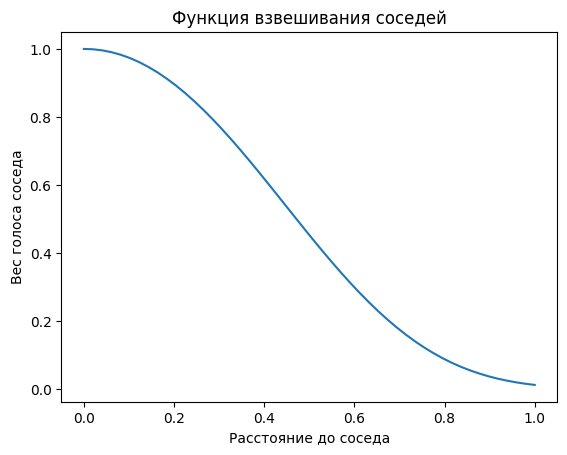

In [52]:
# Создаем массив из 50 равномерно распределенных чисел от 0 до 1
x = np.linspace(0, 1)

plt.plot(x, distance2vote(x))

plt.xlabel('Расстояние до соседа')  # Подпись оси X
plt.ylabel('Вес голоса соседа')     # Подпись оси Y
plt.title('Функция взвешивания соседей')  # Заголовок графика

In [54]:
from tqdm.auto import tqdm, trange

In [55]:
words, vectors, synset_ids = [], [], []

# Перебираем все синсеты в тезаурусе с отображением прогресса
for synset in tqdm(wn.synsets):
    # Пропускаем все части речи кроме глаголов
    if synset.part_of_speech != 'V':
        continue

    # Для каждого синсета обрабатываем все его смыслы
    for sense in synset.senses:
        words.append(sense.name)
        vectors.append(vectorize(sense.name))
        synset_ids.append(synset.id)

# Объединяем все векторы в единую матрицу
# Каждая строка матрицы - векторное представление одного слова
vectors = np.stack(vectors)

  0%|          | 0/59905 [00:00<?, ?it/s]

In [56]:
tree = KDTree(vectors)

In [57]:
arrays = [np.random.randn(3, 4) for _ in range(10)]

# Выводим первый массив для примера
arrays[0]

# Объединяем все массивы в один многомерный массив
# np.stack() складывает массивы по указанной оси (axis=0)
# Результат будет иметь размерность (10, 3, 4):
# - 10 массивов
# - каждый массив размером 3x4
np.stack(arrays, axis=0).shape

(10, 3, 4)

In [58]:
tree = KDTree(vectors)

In [59]:
votes = Counter()

# Находим 100 ближайших соседей для вектора слова "кудахтать" в векторном пространстве
dists, ids = tree.query(vectorize('кудахтать').reshape(1, -1), k=100)

# Для каждого найденного соседа
for idx, distance in zip(ids[0], dists[0]):
    # Получаем все гиперонимы синсета этого соседа
    for hyper in wn[synset_ids[idx]].hypernyms:
        # Увеличиваем счетчик для данного гиперонима на значение,
        # зависящее от расстояния до соседа (чем ближе сосед, тем больше голос)
        votes[hyper.id] += distance2vote(distance)

    print(words[idx], [t.title for t in wn[synset_ids[idx]].hypernyms])

КУДАХТАТЬ ['ИЗДАТЬ ЗВУК']
ПАХТАТЬ ['СБИТЬ В ПЛОТНУЮ МАССУ']
РАСКУДАХТАТЬСЯ ['ИЗДАТЬ ЗВУК']
КЛОХТАТЬ ['ИЗДАТЬ ЗВУК']
СБЕГАТЬ ТУДА И ОБРАТНО ['СХОДИТЬ ТУДА И ОБРАТНО']
БАРАХТАТЬСЯ ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ', 'ПЛЕСКАТЬСЯ В ВОДЕ']
СНОВАТЬ ТУДА-СЮДА ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
СХОДИТЬ ТУДА И ОБРАТНО ['ИДТИ НОГАМИ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
ПОДЛАТАТЬ ['ЗАШИТЬ ДЫРУ', 'НАШИТЬ СВЕРХУ']
ЗАНЫРНУТЬ ['ПОГРУЗИТЬСЯ В ЖИДКОСТЬ']
СНОВАТЬ ТУДА И ОБРАТНО ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
ПОПРЯТАТЬ ['ОБЕРЕГАТЬ, ЗАЩИЩАТЬ']
ПОПРЯТАТЬ ['НАКРЫТЬ, ПОКРЫТЬ СВЕРХУ']
СПЛАВАТЬ ТУДА И ОБРАТНО ['ПЛЫТЬ (ПЕРЕДВИГАТЬСЯ ПО ВОДЕ)', 'ПЛЫТЬ НА СУДНЕ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
РЫПАТЬСЯ ['ПЫТАТЬСЯ, СТАРАТЬСЯ', 'ХОТЕТЬ, ИМЕТЬ ЖЕЛАНИЕ']
СБЕГАТЬ И ВЕРНУТЬСЯ ['СХОДИТЬ ТУДА И ОБРАТНО']
БУРЧАТЬ ['ИЗДАТЬ ЗВУК']
БУРЧАТЬ ['БОРМОТАТЬ']
ПЕРЕБАРЫВАТЬ ['ПРЕОДОЛЕТЬ']
ПЕРЕБАРЫВАТЬ ['ПРЕВЗОЙТИ']
БРАТЬСЯ ['ПОЛУЧИТЬ В РАСПОРЯЖЕНИЕ']
БРАТЬСЯ ['ПОЯВИТЬСЯ, ВОЗНИКНУТЬ, НАЧАТЬСЯ']
БРАТЬСЯ ['НАЧАТЬ, ПРИСТУПИТЬ, ПРИНЯТЬСЯ', 'ОБЯЗАТЬСЯ']
БРАТЬСЯ ['БРАТЬ 

In [60]:
#10 наиболее семантически близких к данному слову гиперонимов
for sid, score in votes.most_common(10):
    print(score,  wn[sid].title)

1.693910435463562 ИЗДАТЬ ЗВУК
0.4132547441687813 ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ
0.3097076148668363 СБИТЬ В ПЛОТНУЮ МАССУ
0.25169095401266095 СПУСТИТЬСЯ ВНИЗ
0.22120903181668677 СХОДИТЬ ТУДА И ОБРАТНО
0.20195221302283534 ОБЕРНУТЬСЯ ТУДА И ОБРАТНО
0.1896130809969685 ЗАШИТЬ ДЫРУ
0.1896130809969685 НАШИТЬ СВЕРХУ
0.18951210591007633 ИДТИ НОГАМИ
0.1778837765054719 КАЧАТЬ (КОЛЕБАТЬ)


Найти лишнее слово

ДИВАН, ШКАФ, ЛАМПА, СТОЛ

In [61]:
import math


def get_all_hypernyms(wn, word, max_level=100):
    """ Return dict of all hypernyms of a word and their distances """
    """Возвращает все гиперонимы слова word и их расстояния"""
    # Получаем список всех синсетов для данного слова
    front = [sense.synset for sense in wn.get_senses(word)]
    # Словарь для хранения уровней гиперонимов
    levels = {}

    # Проходим по уровням иерархии гиперонимов
    for level in range(max_level):
        if not front:  # Если больше нет гиперонимов для обработки
            break
        new_front = []
        for synset in front:
            if synset.id not in levels:
                # Сохраняем уровень гиперонима (чем меньше уровень, тем ближе к исходному слову)
                levels[synset.id] = level
                # Добавляем гиперонимы текущего синсета для следующей итерации
                new_front.extend(synset.hypernyms)
        front = new_front
    return levels

def get_closest_common(levels1, levels2):
    """ Find the closest common hypernym and sum of distances to it"""
    """Возвращает самый близкий общий гипероним и сумму расстояний до него"""
    result = None
    result_distance = math.inf  # Инициализируем максимально возможным расстоянием

    # Ищем общие гиперонимы и выбираем ближайший
    for id, distance in levels1.items():
        if id in levels2:  # Если гипероним есть в обоих словах
            total = distance + levels2[id]  # Суммируем расстояния до общего гиперонима
            if total < result_distance:  # Если нашли более близкий общий гипероним
                result_distance = total
                result = id
    return result, result_distance

In [62]:
words = ['ДИВАН', 'ШКАФ', 'ЛАМПА', 'СТОЛ']

print('\t\t', '\t'.join(words))

# Для каждого слова в списке
for w1 in words:
    print(w1, end='\t')
    for w2 in words:
        n, d = get_closest_common(get_all_hypernyms(wn, w1), get_all_hypernyms(wn, w2))
        print(d, end='\t\t')
    # Переходим на новую строку после обработки всех пар с текущим словом
    print()

		 ДИВАН	ШКАФ	ЛАМПА	СТОЛ
ДИВАН	0		3		10		3		
ШКАФ	3		0		5		2		
ЛАМПА	10		5		0		7		
СТОЛ	3		2		7		0		


In [65]:
# Находим ближайший общий гипероним между словами "лампа" и "шкаф"
name, distance = get_closest_common(get_all_hypernyms(wn, 'лампа'), get_all_hypernyms(wn, 'шкаф'))
print(distance, name, wn[name].title)

5 106555-N ТЕХНИЧЕСКОЕ УСТРОЙСТВО


In [66]:
for k, v in get_all_hypernyms(wn, 'лампа').items():
    print(k, v, wn[k])

128561-N 0 Synset(id="128561-N", title="ОСВЕТИТЕЛЬНЫЙ ПРИБОР")
8785-N 0 Synset(id="8785-N", title="ЭЛЕКТРИЧЕСКАЯ ЛАМПА")
107646-N 1 Synset(id="107646-N", title="ИСТОЧНИК ОСВЕЩЕНИЯ")
4222-N 1 Synset(id="4222-N", title="СВЕТОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106488-N 2 Synset(id="106488-N", title="ИСХОДНЫЙ ПУНКТ")
2070-N 2 Synset(id="2070-N", title="ЭЛЕКТРОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106613-N 3 Synset(id="106613-N", title="РОЛЬ, ПОЛОЖЕНИЕ, МЕСТО")
149201-N 3 Synset(id="149201-N", title="ИНЖЕНЕРНОЕ ОБОРУДОВАНИЕ")
106555-N 4 Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО")
1320-N 4 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")
106553-N 5 Synset(id="106553-N", title="ПРИСПОСОБЛЕНИЕ (ПРЕДМЕТ)")
106554-N 6 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
147133-N 7 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
147134-N 8 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
153782-N 9 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")


Word Sense Disambiguation (WSD)

In [67]:
!pip install razdel

In [68]:
import razdel

зАмок или замОк?

In [69]:
context = '''Сначала шов слегка уплотняем молоточком, затем прочеканиваем на нём замок
― бороздку, называемую "зигом", которая будет препятствовать расхождению шва при дальнейшем его уплотнении.'''
word = 'замок'

In [70]:
def disambiguate(word, context):
    # Получаем список синсетов (значений) для заданного слова
    candidates = [s.synset for s in wn[word]]

    # Токенизируем контекст и создаем вектор для всего текста, исключая целевое слово
    text_vector = vectorize(' '.join(t.text for t in razdel.tokenize(context) if t.text != word))

    # Для каждого синсета-кандидата создаем вектор на основе его синонимов
    candidate_vectors = [
        vectorize(' '.join(w for s in c.senses for w in s.name.lower().split() if name != word))
        for c in candidates
    ]

    # Вычисляем косинусное сходство между вектором контекста и векторами кандидатов
    scores = [np.dot(text_vector, v) for v in candidate_vectors]

    # Возвращаем словарь {сходство: синсет} для каждого кандидата
    return dict(zip(scores, candidates))

In [71]:
disambiguate(word, context)

{0.4421322748905842: Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК"),
 0.55319632362594: Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")}

In [72]:
# Функция для векторизации текста (среднее по словам, исключая короткие)
def vectorize(text, ft):
    vecs = [ft[word] for word in text.lower().split() if len(word) >= 3 and word in ft]
    if not vecs:
        return np.zeros(ft.vector_size)
    vec = np.mean(vecs, axis=0)
    return vec / np.linalg.norm(vec)

In [73]:
# Функция для определения правильного смысла слова в контексте
def disambiguate(word, context, wn, ft):
    candidates = [sense.synset for sense in wn[word]]
    # Векторизуем контекст (без самой слова)
    context_tokens = [t.text for t in razdel.tokenize(context) if t.text.lower() != word.lower()]
    context_vector = vectorize(' '.join(context_tokens), ft)

    scores = {}
    for synset in candidates:
        # Векторизуем все синонимы синонима
        synonyms = ' '.join(sense.name for sense in synset.senses)
        synset_vector = vectorize(synonyms, ft)
        # Косинусное сходство между контекстом и синонимами
        score = np.dot(context_vector, synset_vector)
        scores[synset] = score

    # Выбираем смысл с максимальным баллом
    best_sense = max(scores, key=scores.get)
    return best_sense, scores[best_sense]

Примеры

In [74]:
context = "Печень является важным органом для детоксикации."
word = "орган"

In [75]:
# Загружаем сжатую модель FastText (векторное представление слов)
ft = compress_fasttext.models.CompressedFastTextKeyedVectors.load(
    'https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin'
)

In [76]:
best_sense, score = disambiguate(word, context, wn, ft)
print(f"Лучший смысл: {best_sense.title}, оценка: {score}")

Лучший смысл: ОРГАН ЖИВОГО ОРГАНИЗМА, оценка: 0.7052275534581904


In [78]:
context = "В филармонию принесли орган."
word = "орган"

In [79]:
best_sense, score = disambiguate(word, context, wn, ft)
print(f"Лучший смысл: {best_sense.title}, оценка: {score}")

Лучший смысл: ОРГАН (МУЗЫКАЛЬНЫЙ ИНСТРУМЕНТ), оценка: 0.4805523251188581


In [80]:
context = '''Сначала шов слегка уплотняем молоточком, затем прочеканиваем на нём замок
― бороздку, называемую "зигом", которая будет препятствовать расхождению шва при дальнейшем его уплотнении.'''
word = 'замок'

In [81]:
best_sense, score = disambiguate(word, context, wn, ft)
print(f"Лучший смысл: {best_sense.title}, оценка: {score}")

Лучший смысл: ЗАМОК ДЛЯ ЗАПИРАНИЯ, оценка: 0.5531963236259403


Видим, что зАмок (для запирания) более вероятен